In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


# Placement of Activation Function

## Hidden Layers

Activation functions in hidden layers introduce **non-linearity** into the network.
Without them, stacking linear transformations still yields a single linear mapping,
no matter how many layers you add. The network could not learn curved decision boundaries.

**ReLU (and its variants) is the standard choice here.**

Each hidden layer typically follows the pattern:

```
Linear → Activation → (next layer)
```

The activation fires after the weight transformation, shaping what gets passed forward.
In deeper networks this happens repeatedly, letting the model compose increasingly
abstract representations layer by layer.

## Output Layer

The output layer activation depends entirely on the **task**, not on learning capacity.
Its job is to map the final hidden representation into the correct output format.

| Task | Output Activation | Why |
|---|---|---|
| Binary classification | Sigmoid | Squashes output to (0, 1) → interpretable as probability |
| Multi-class classification | Softmax | Produces a probability distribution across classes (sums to 1) |
| Regression | None (linear) | Output can be any real value; clipping it would distort predictions |
| Multi-label classification | Sigmoid (per neuron) | Each class is an independent binary decision |



# Sigmoid Activation Function for Binary Classification

* Sigmoid in last layer of network of linear layers is EQUIVALENT to traditional logistic regression.

* For example, question is to determine whether one animal is mammal ore not
    * input:
        * limbs: 4, eggs:0 , hair:1
        * passing them to a linear layer:
            * 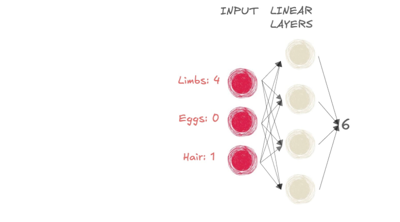
        * after sigmoid we recieve
                *


In [ ]:
input_tensor = torch.tensor([[6]])  #6 being here final output of an linear network

sigmoid = nn.Sigmoid()
output = sigmoid(input_tensor)
output


# Softmax Activation Function for Multiclass Classification

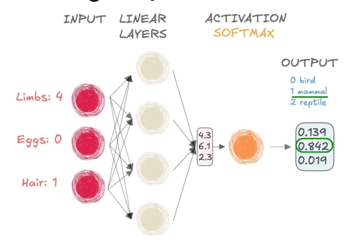

* Output is a probability distrubution
* Each element is a proability between 0 and 1, sum is 1
* Shows how likely it is to belong to a sepcific group

In [7]:
input_tensor = torch.tensor([[4.3,6.1,2.3]])

# dim -1 ensures: applying to the LAST DIMENSION
probabilities = nn.Softmax(dim=-1)
output_tensor = probabilities(input_tensor)
output_tensor


tensor([[0.1392, 0.8420, 0.0188]])

## Vanishing Gradients Problem for Softmax/ Sigmoid

![image.png](attachment:486a2039-c5a0-47bc-a1cd-672a08017837.png)

* Gradients of softmax at extremes (for large and small values of x) are very low
* This repeats over time and gradients lose its meaning

# ReLU
Rectified Linear Unit

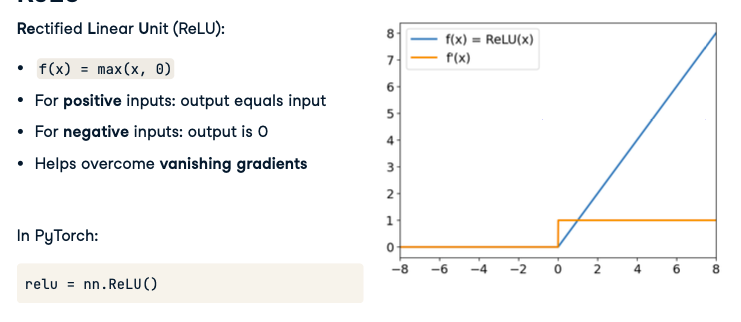

#### Why it matters:

Sigmoid and tanh saturate at extreme values, pushing gradients toward zero and stalling learning in deep networks. ReLU keeps the gradient at 1 for all positive inputs, so deep networks can actually train.

It also produces sparsity: negative inputs get zeroed out, meaning only a subset of neurons fire at any given time. This tends to improve generalization.

#### Dying ReLU problem:
If a neuron consistently receives negative inputs, its gradient stays 0 forever and it stops learning. Variants like Leaky ReLU, ELU, and GELU address this with softer negative-side behavior.
In PyTorch: nn.ReLU() as a module, or F.relu(x) as a functional call.

# Leaky ReLU

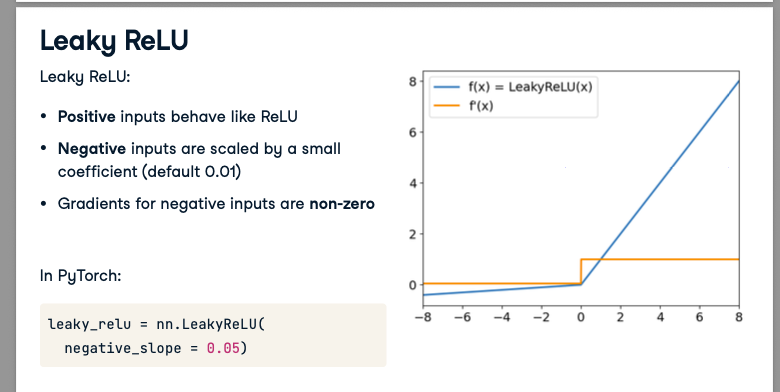

Standard ReLU zeros out everything negative. If a neuron's pre-activation output is consistently negative (which can happen after a bad weight update), its gradient becomes permanently 0 and it never recovers. That neuron is dead for the rest of training.Leaky ReLU solves this by keeping a small slope α on the negative side. The gradient never fully vanishes, so the neuron can still receive updates and **potentially recover.**


When to prefer Leaky ReLU over ReLU: when you observe dead neurons during training (weights that stop updating, neurons that always output 0), or when training very deep networks where gradient flow is fragile. In many standard architectures ReLU works fine, so Leaky ReLU is more of a debugging/robustness tool than a default replacement.



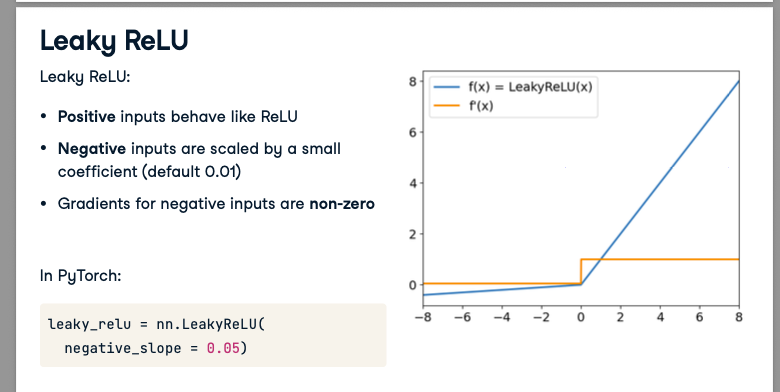